<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 3 - Phase 3_1 - eyamrog

The aim of this phase is to retrieve data about QJPP for the dissertation.

## Required Python packages

- pandas
- matplotlib

## Import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Define input variables

In [2]:
input_directory = 'cl_st3_ph3_eyamrog'
output_directory = 'cl_st3_ph3_eyamrog'

## Final `QJPP`

### Import the data into a DataFrame

In [3]:
df_qjpp_balanced = pd.read_json(f"{input_directory}/df_qjpp_balanced.jsonl", lines=True)

In [4]:
df_qjpp_balanced['Published'] = pd.to_datetime(df_qjpp_balanced['Published'], unit='ms')

#### Correct the `Discipline` column

In [5]:
discipline_correction_dict = {
    'Linguistic, literature and arts': 'Linguistics, Literature, and Arts'
}

In [6]:
# Correct the 'Discipline' column using the mapping dictionary
df_qjpp_balanced['Discipline'] = df_qjpp_balanced['Discipline'].replace(discipline_correction_dict)

### Reassess the balance

In [7]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp_balanced.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Count',
    'Paragraph_Counts': 'Paragraph Count'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Count'] / df_balancing['Text Count']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Count'] = df_balancing['Paragraph Count'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Count,Paragraph Count,Average Paragraph Count per Text,Balanced Paragraph Count
0,Biological Sciences,35,2077,59.342857,2077
1,Human Sciences,44,1980,45.000000,3960
2,Health Sciences,45,1889,41.977778,5667
3,Applied Social Sciences,42,1840,43.809524,7360
4,"Linguistics, Literature, and Arts",29,1713,59.068966,8565


In [8]:
x_label = 'Discipline'
y_label = 'Paragraph Count'
title = 'Paragraph Count per Discipline'
filename = 'df_qjpp_paragraph_count_per_discipline2'
plot_filename = f"{filename}.png"

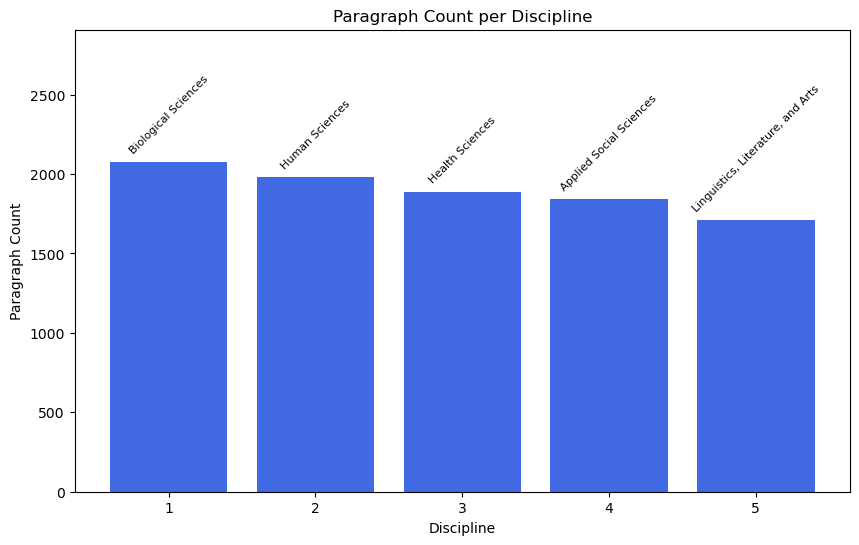

In [9]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Paragraph Count']

# Disciplines for labels
labels = df_balancing['Discipline']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

### Create a LaTeX table

In [10]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [11]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [12]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

### Assess the balance of `Paragraph Count` per `Section` per `Discipline`

In [13]:
# Group by 'Section' and 'Discipline' to count the number of paragraphs
df_section_paragraph = df_qjpp_balanced.groupby(['Section', 'Discipline']).size().reset_index(name='Paragraph Count')

# Display the resulting DataFrame
df_section_paragraph

,Section,Discipline,Paragraph Count
0,Abstract,Applied Social Sciences,67
1,Abstract,Biological Sciences,69
2,Abstract,Health Sciences,114
3,Abstract,Human Sciences,44
4,Abstract,"Linguistics, Literature, and Arts",29
...,...,...,...
59,Results,Human Sciences,244
60,Results,"Linguistics, Literature, and Arts",268
61,"Results, Discussion",Applied Social Sciences,86
62,"Results, Discussion",Health Sciences,29


### Create a LaTeX table

In [14]:
title = 'Paragraph Count per Section per Discipline'
filename = 'df_qjpp_paragraph_count_per_section_per_discipline'

In [15]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [16]:
tex_table = df_section_paragraph.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [17]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

## Final `QJPP` - Translate into Brazilian Portuguese

### Import the data into a DataFrame

In [18]:
df_qjpp_balanced = pd.read_json(f"{input_directory}/df_qjpp_balanced.jsonl", lines=True)

In [19]:
df_qjpp_balanced['Published'] = pd.to_datetime(df_qjpp_balanced['Published'], unit='ms')

#### Correct the `Discipline` column and translate it

In [20]:
discipline_correction_dict = {
    'Linguistic, literature and arts': 'Linguistics, Literature, and Arts'
}

In [21]:
# Correct the 'Discipline' column using the mapping dictionary
df_qjpp_balanced['Discipline'] = df_qjpp_balanced['Discipline'].replace(discipline_correction_dict)

In [22]:
discipline_ptbr_dict = {
    'Exact and Earth Sciences': 'Ciências Exatas e da Terra',
    'Biological Sciences': 'Ciências Biológicas',
    'Engineering': 'Engenharias',
    'Health Sciences': 'Ciências da Saúde',
    'Agricultural Sciences': 'Ciências Agrárias',
    'Applied Social Sciences': 'Ciências Sociais Aplicadas',
    'Human Sciences': 'Ciências Humanas',
    'Linguistics, Literature, and Arts': 'Linguística, Letras, e Artes'
}

In [23]:
# Correct the 'Discipline' column using the mapping dictionary
df_qjpp_balanced['Discipline'] = df_qjpp_balanced['Discipline'].replace(discipline_ptbr_dict)

### Reassess the balance

In [24]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp_balanced.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Discipline': 'Disciplina',
    'Text_Counts': 'Contagem de Textos',
    'Paragraph_Counts': 'Contagem de Parágrafos'
}, inplace=True)

# Sort the DataFrame by 'Contagem de Parágrafos' in descending order
df_balancing = df_balancing.sort_values(by='Contagem de Parágrafos', ascending=False).reset_index(drop=True)

# Add 'Contagem Média de Parágrafos por Texto'
df_balancing['Contagem Média de Parágrafos por Texto'] = df_balancing['Contagem de Parágrafos'] / df_balancing['Contagem de Textos']

# Add 'Contagem de Parágrafos Balanceada' using direct computation with the index
df_balancing['Contagem de Parágrafos Balanceada'] = df_balancing['Contagem de Parágrafos'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Disciplina,Contagem de Textos,Contagem de Parágrafos,Contagem Média de Parágrafos por Texto,Contagem de Parágrafos Balanceada
0,Ciências Biológicas,35,2077,59.342857,2077
1,Ciências Humanas,44,1980,45.000000,3960
2,Ciências da Saúde,45,1889,41.977778,5667
3,Ciências Sociais Aplicadas,42,1840,43.809524,7360
4,"Linguística, Letras, e Artes",29,1713,59.068966,8565


In [25]:
x_label = 'Disciplina'
y_label = 'Contagem de Parágrafos'
title = 'Contagem de Parágrafos por Disciplina'
filename = 'df_qjpp_paragraph_count_per_discipline2_ptbr'
plot_filename = f"{filename}.png"

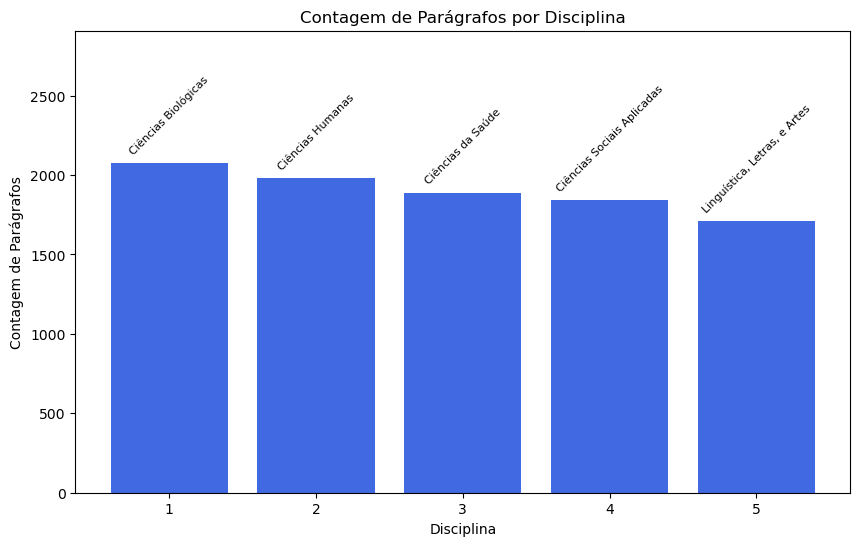

In [26]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Contagem de Parágrafos']

# Disciplines for labels
labels = df_balancing['Disciplina']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

### Create a LaTeX table

In [27]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [28]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [29]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

### Assess the balance of `Paragraph Count` per `Section` per `Discipline`

In [30]:
# Rename the columns
df_qjpp_balanced.rename(columns={
    'Discipline': 'Disciplina',
    'Section': 'Seção',
    'Text_Counts': 'Contagem de Textos',
    'Paragraph_Counts': 'Contagem de Parágrafos'
}, inplace=True)

# Group by 'Section' and 'Discipline' to count the number of paragraphs
df_section_paragraph = df_qjpp_balanced.groupby(['Seção', 'Disciplina']).size().reset_index(name='Contagem de Parágrafos')

# Display the resulting DataFrame
df_section_paragraph

,Seção,Disciplina,Contagem de Parágrafos
0,Abstract,Ciências Biológicas,69
1,Abstract,Ciências Humanas,44
2,Abstract,Ciências Sociais Aplicadas,67
3,Abstract,Ciências da Saúde,114
4,Abstract,"Linguística, Letras, e Artes",29
...,...,...,...
59,Results,Ciências da Saúde,392
60,Results,"Linguística, Letras, e Artes",268
61,"Results, Discussion",Ciências Sociais Aplicadas,86
62,"Results, Discussion",Ciências da Saúde,29


### Create a LaTeX table

In [31]:
title = 'Contagem de Parágrafos por Seção por Disciplina'
filename = 'df_qjpp_paragraph_count_per_section_per_discipline_ptbr'

In [32]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [33]:
tex_table = df_section_paragraph.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [34]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)